#  Factor Selection on Train Segment
---

In [74]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr, f_oneway
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
np.random.seed(42)

DATA_DIR = Path('data')
OUT_DIR = Path('data')
OUT_DIR.mkdir(exist_ok=True)

In [75]:
factors = pd.read_parquet(DATA_DIR / 'spy_factors_step2.parquet')
meta = pd.read_csv(DATA_DIR / 'spy_factors_step2_meta.csv')

with open(DATA_DIR / 'splits.json', 'r') as f:
    splits = json.load(f)

train_start = pd.Timestamp(splits['train']['start'])
train_end   = pd.Timestamp(splits['train']['end'])

print(f"Factor matrix: {factors.shape}")
print(f"Train: {train_start.date()} → {train_end.date()}")
print(f"\nFactor metadata:\n{meta}")

Factor matrix: (2745, 25)
Train: 2017-01-05 → 2023-04-25

Factor metadata:
               factor category version  burn_in
0           RV_open30        A    main        0
1          RV_close30        A    main        0
2       RV_close30_nc        A      nc        0
3          VolPattern        A    main        0
4             PathEff        B    main        0
5          VWAP_Cross        B    main        0
6            CloseLoc        B    main        0
7        SignedVolume        C    main      252
8             VolGini        C    main      252
9        PriceVolCorr        C    main      252
10   SignedVolume_raw        C     raw        0
11        VolGini_raw        C     raw        0
12   PriceVolCorr_raw        C     raw        0
13  SignedVolume_z252        C    z252      504
14       VolGini_z252        C    z252      504
15  PriceVolCorr_z252        C    z252      504
16                 BV        D    main        0
17               Jump        D    main        0
18           

---
## 3.Load SPY Daily Close for r_{t+1} Target

In [76]:
spy_min = pd.read_parquet(DATA_DIR / 'spy_minute_clean.parquet')
spy_min.index = pd.to_datetime(spy_min.index)

daily_close = spy_min['close'].resample('D').last().dropna()
daily_close.index = daily_close.index.normalize()

r_next = np.log(daily_close.shift(-1) / daily_close)
r_next.name = 'r_next'

print(f"Daily close range: {daily_close.index.min().date()} → {daily_close.index.max().date()}")
print(f"r_next non-NaN count: {r_next.notna().sum()}")

Daily close range: 2015-01-02 → 2025-12-31
r_next non-NaN count: 2744


---
## 4.Define Candidate Pools

In [77]:
X_HMM_CANDIDATES = ['RV_open30', 'RV_close30', 'BV', 'Jump', 'SignedJump',
                    'VolGini_z252', 'VR_5_1','Ret_1d','Mom_20d','Mom_60d']

X_P_CANDIDATES = ['SignedVolume_z252', 'PriceVolCorr_z252', 'CloseLoc',
                  'PathEff', 'VWAP_Cross', 'Overnight', 'SignedJump','Ret_1d','Mom_20d','Mom_60d']

---
## 5.Build Train Slice

In [78]:
factors.index = factors.index.normalize()

mask_train = (factors.index >= train_start) & (factors.index <= train_end)
F_train = factors.loc[mask_train].copy()

r_next_train = r_next.reindex(F_train.index)

valid_mask = r_next_train.notna()
F_train = F_train.loc[valid_mask]
r_next_train = r_next_train.loc[valid_mask]

---
## 6.Helper Functions

In [79]:
def newey_west_tstat(x, y, lags=5):
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 30:
        return np.nan, np.nan
    rx = pd.Series(x).rank().values
    ry = pd.Series(y).rank().values
    rx = (rx - rx.mean()) / rx.std()
    ry = (ry - ry.mean()) / ry.std()
    X_design = sm.add_constant(rx)
    model = sm.OLS(ry, X_design).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return model.params[1], model.tvalues[1]

def rank_ic(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 30:
        return np.nan
    return spearmanr(x[mask], y[mask])[0]

def rolling_ic(x, y, window=252):
    s = pd.Series(index=x.index, dtype=float)
    for i in range(window, len(x) + 1):
        xi = x.iloc[i-window:i]
        yi = y.iloc[i-window:i]
        m = np.isfinite(xi) & np.isfinite(yi)
        if m.sum() >= window // 2:
            s.iloc[i-1] = spearmanr(xi[m], yi[m])[0]
    return s

def log_scaled(x, scale=1e4):
    return np.log1p(np.maximum(x, 0) * scale)

def signed_log_scaled(x, scale=1e4):
    return np.sign(x) * np.log1p(np.abs(x) * scale)

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

---
## 8.X_HMM — Transform Decision & Skewness/Kurtosis Comparison

In [80]:
HMM_TRANSFORMS = {
    'RV_open30':    ('log_scaled_1e5',        lambda x: log_scaled(x, 1e5)),
    'RV_close30':   ('log_scaled_1e5',        lambda x: log_scaled(x, 1e5)),
    'BV':           ('log_scaled_1e4',        lambda x: log_scaled(x, 1e4)),
    'Jump':         ('log_scaled_1e5',        lambda x: log_scaled(x, 1e5)),
    'SignedJump':   ('signed_log_scaled_1e5', lambda x: signed_log_scaled(x, 1e5)),
    'VolGini_z252': ('identity',              lambda x: x),
    'VR_5_1':       ('identity',              lambda x: x),
    'Ret_1d':       ('identity',              lambda x: x),
    'Mom_20d':      ('identity',              lambda x: x),
    'Mom_60d':      ('identity',              lambda x: x),
}

hmm_transform_report = []
for f in X_HMM_CANDIDATES:
    raw = F_train[f].dropna()
    name, fn = HMM_TRANSFORMS[f]
    tfm = fn(raw)
    hmm_transform_report.append({
        'factor': f,
        'transform': name,
        'kurt_raw': raw.kurt(),
        'kurt_tfm': tfm.kurt(),
        'skew_raw': raw.skew(),
        'skew_tfm': tfm.skew(),
        'mean_tfm': tfm.mean(),
        'std_tfm': tfm.std(),
    })

hmm_transform_df = pd.DataFrame(hmm_transform_report)
print(hmm_transform_df.to_string(index=False))

      factor             transform   kurt_raw  kurt_tfm  skew_raw  skew_tfm  mean_tfm  std_tfm
   RV_open30        log_scaled_1e5 180.053177  5.765059 11.216435  1.946303  0.570333 0.508188
  RV_close30        log_scaled_1e5 177.756989  9.412008 11.088756  2.627673  0.466441 0.519079
          BV        log_scaled_1e4 117.265112  5.912591  9.077964  1.988912  0.469382 0.449332
        Jump        log_scaled_1e5 170.861467  6.633490  9.431095  2.426533  0.256333 0.397513
  SignedJump signed_log_scaled_1e5  71.787292  4.599881  1.870271  0.311006 -0.006564 0.594502
VolGini_z252              identity   1.142929  1.142929  0.694276  0.694276 -0.080635 1.049199
      VR_5_1              identity   2.478581  2.478581 -0.956600 -0.956600  0.930182 0.228987
      Ret_1d              identity   6.341859  6.341859 -0.228047 -0.228047  0.000372 0.011504
     Mom_20d              identity  11.413009 11.413009 -2.003987 -2.003987  0.007601 0.050067
     Mom_60d              identity   2.625200  2.6

---
## 11.X_HMM — Univariate GMM Fitting (BIC/AIC for K=1,2,3,4)

In [81]:
gmm_rows = []
for f in X_HMM_CANDIDATES:
    raw = F_train[f].dropna()
    name, fn = HMM_TRANSFORMS[f]
    tfm = fn(raw).dropna().values.reshape(-1, 1)
    if len(tfm) < 200:
        continue
    bic_list, aic_list = {}, {}
    for K in [1, 2, 3, 4]:
        gmm = GaussianMixture(n_components=K, covariance_type='full',
                              random_state=42, n_init=5, max_iter=300)
        gmm.fit(tfm)
        bic_list[K] = gmm.bic(tfm)
        aic_list[K] = gmm.aic(tfm)
    gmm_rows.append({
        'factor': f,
        'BIC_K1': bic_list[1], 'BIC_K2': bic_list[2],
        'BIC_K3': bic_list[3], 'BIC_K4': bic_list[4],
        'dBIC_K2_vs_K1': bic_list[1] - bic_list[2],
        'dBIC_K3_vs_K1': bic_list[1] - bic_list[3],
        'best_K_by_BIC': min(bic_list, key=bic_list.get),
    })

gmm_df = pd.DataFrame(gmm_rows).sort_values('dBIC_K2_vs_K1', ascending=False)
print(gmm_df.to_string(index=False))

      factor       BIC_K1       BIC_K2       BIC_K3       BIC_K4  dBIC_K2_vs_K1  dBIC_K3_vs_K1  best_K_by_BIC
        Jump  1571.450003  -400.889080 -2704.185157 -2978.284725    1972.339083    4275.635159              4
  RV_close30  2408.758734  1204.085766   974.298329   697.512689    1204.672968    1434.460405              4
          BV  1955.968951  1085.806499   862.849771   715.568061     870.162452    1093.119181              4
   RV_open30  2342.222248  1547.485134  1359.664328  1262.867586     794.737113     982.557919              4
  SignedJump  2834.489689  2347.948130  2380.722529  2379.045760     486.541558     453.767160              2
     Mom_20d -4930.076801 -5374.584566 -5453.609898 -5449.692166     444.507765     523.533097              3
     Mom_60d -3767.370561 -4168.633825 -4161.996385 -4134.145137     401.263264     394.625824              2
      Ret_1d -9544.953369 -9883.486182 -9860.491482 -9869.184737     338.532813     315.538113              2
      VR_5

---
## 12.X_HMM — Pairwise Correlation (|ρ| > 0.85 Threshold)

In [82]:
hmm_tfm_train = pd.DataFrame(index=F_train.index)
for f in X_HMM_CANDIDATES:
    name, fn = HMM_TRANSFORMS[f]
    hmm_tfm_train[f] = fn(F_train[f])

hmm_corr = hmm_tfm_train.corr(method='spearman')
print("X_HMM pairwise Spearman correlation (post-transform):")
print(hmm_corr.round(3).to_string())

print("\nPairs with |ρ| > 0.85:")
for i in range(len(hmm_corr)):
    for j in range(i+1, len(hmm_corr)):
        if abs(hmm_corr.iloc[i, j]) > 0.85:
            print(f"  {hmm_corr.index[i]} ↔ {hmm_corr.columns[j]}: ρ={hmm_corr.iloc[i,j]:.3f}")

X_HMM pairwise Spearman correlation (post-transform):
              RV_open30  RV_close30     BV   Jump  SignedJump  VolGini_z252  VR_5_1  Ret_1d  Mom_20d  Mom_60d
RV_open30         1.000       0.762  0.859  0.246       0.074        -0.495   0.098  -0.096   -0.401   -0.441
RV_close30        0.762       1.000  0.864  0.280      -0.084        -0.434   0.130  -0.230   -0.369   -0.394
BV                0.859       0.864  1.000  0.344      -0.021        -0.447   0.051  -0.179   -0.398   -0.439
Jump              0.246       0.280  0.344  1.000      -0.000        -0.086  -0.114  -0.017   -0.118   -0.138
SignedJump        0.074      -0.084 -0.021 -0.000       1.000        -0.066  -0.032   0.470   -0.001   -0.006
VolGini_z252     -0.495      -0.434 -0.447 -0.086      -0.066         1.000  -0.066   0.068    0.305    0.374
VR_5_1            0.098       0.130  0.051 -0.114      -0.032        -0.066   1.000  -0.056   -0.028   -0.037
Ret_1d           -0.096      -0.230 -0.179 -0.017       0.470     

---
## 13.X_HMM — Final Selection

In [83]:
selected_hmm = ['RV_open30', 'RV_close30', 'Jump', 'VR_5_1','Ret_1d','Mom_20d','Mom_60d']
dropped_hmm = ['BV', 'SignedJump', 'VolGini_z252']

selected_hmm_transforms = {f: HMM_TRANSFORMS[f][0] for f in selected_hmm}

print("=== X_HMM Final Selection ===")
print(f"Selected ({len(selected_hmm)}): {selected_hmm}")
print(f"Dropped  ({len(dropped_hmm)}): {dropped_hmm}")
print(f"\nTransforms:")
for f in selected_hmm:
    print(f"  {f:<12} → {selected_hmm_transforms[f]}")

=== X_HMM Final Selection ===
Selected (7): ['RV_open30', 'RV_close30', 'Jump', 'VR_5_1', 'Ret_1d', 'Mom_20d', 'Mom_60d']
Dropped  (3): ['BV', 'SignedJump', 'VolGini_z252']

Transforms:
  RV_open30    → log_scaled_1e5
  RV_close30   → log_scaled_1e5
  Jump         → log_scaled_1e5
  VR_5_1       → identity
  Ret_1d       → identity
  Mom_20d      → identity
  Mom_60d      → identity


---
## 14.X_P — Pre-processing Map

In [84]:
P_TRANSFORMS = {
    'SignedVolume_z252': ('identity',              lambda x: x),
    'PriceVolCorr_z252': ('identity',              lambda x: x),
    'CloseLoc':          ('identity',              lambda x: x),
    'PathEff':           ('identity',              lambda x: x),
    'VWAP_Cross':        ('identity',              lambda x: x),
    'Overnight':         ('signed_log_scaled_1e2', lambda x: signed_log_scaled(x, 1e2)),
    'SignedJump':        ('signed_log_scaled_1e5', lambda x: signed_log_scaled(x, 1e5)),
    'Ret_1d':       ('identity',              lambda x: x),
    'Mom_20d':      ('identity',              lambda x: x),
    'Mom_60d':      ('identity',              lambda x: x),
}
P_train_tfm = pd.DataFrame(index=F_train.index)
for f in X_P_CANDIDATES:
    name, fn = P_TRANSFORMS[f]
    P_train_tfm[f] = fn(F_train[f])

print("X_P transformed kurtosis check:")
for f in X_P_CANDIDATES:
    name, fn = P_TRANSFORMS[f]
    print(f"  {f:<22} ({name:<13}): kurt_raw={F_train[f].kurt():>8.2f}, kurt_tfm={P_train_tfm[f].kurt():>8.2f}")

X_P transformed kurtosis check:
  SignedVolume_z252      (identity     ): kurt_raw=    4.32, kurt_tfm=    4.32
  PriceVolCorr_z252      (identity     ): kurt_raw=    0.74, kurt_tfm=    0.74
  CloseLoc               (identity     ): kurt_raw=   -1.26, kurt_tfm=   -1.26
  PathEff                (identity     ): kurt_raw=    0.11, kurt_tfm=    0.11
  VWAP_Cross             (identity     ): kurt_raw=    0.11, kurt_tfm=    0.11
  Overnight              (signed_log_scaled_1e2): kurt_raw=   24.10, kurt_tfm=    1.56
  SignedJump             (signed_log_scaled_1e5): kurt_raw=   71.79, kurt_tfm=    4.60
  Ret_1d                 (identity     ): kurt_raw=    6.34, kurt_tfm=    6.34
  Mom_20d                (identity     ): kurt_raw=   11.41, kurt_tfm=   11.41
  Mom_60d                (identity     ): kurt_raw=    2.63, kurt_tfm=    2.63


---
## 15.X_P — Rank-IC, Newey-West t-stat, 5-Quantile Monotonicity

In [85]:
p_base_rows = []
for f in X_P_CANDIDATES:
    x = P_train_tfm[f]
    y = r_next_train
    ic_full = rank_ic(x.values, y.values)
    coef_nw, t_nw = newey_west_tstat(x.values, y.values, lags=5)
    p_base_rows.append({
        'factor': f,
        'rank_IC': ic_full,
        'NW_tstat': t_nw,
    })

p_base_df = pd.DataFrame(p_base_rows).sort_values('NW_tstat',
                                                  key=lambda s: s.abs(),
                                                  ascending=False)
print(p_base_df.to_string(index=False))

           factor   rank_IC  NW_tstat
         CloseLoc -0.034219 -1.397392
SignedVolume_z252 -0.021150 -0.888345
          Mom_20d -0.022336 -0.812819
       VWAP_Cross -0.018853 -0.713441
           Ret_1d -0.015322 -0.585689
          Mom_60d -0.014709 -0.560478
        Overnight -0.015577 -0.558961
PriceVolCorr_z252  0.008952  0.377983
          PathEff  0.002801  0.115537
       SignedJump  0.000309  0.010961


---
## 16.X_P — 252-Day Rolling IC Stability

In [86]:
roll_stats_rows = []
roll_ic_dict = {}
for f in X_P_CANDIDATES:
    s = rolling_ic(P_train_tfm[f], r_next_train, window=252).dropna()
    roll_ic_dict[f] = s
    main_sign = np.sign(s.median())
    same_sign_pct = (np.sign(s) == main_sign).mean()
    roll_stats_rows.append({
        'factor': f,
        'roll_IC_mean': s.mean(),
        'roll_IC_std': s.std(),
        'main_sign': int(main_sign),
        'same_sign_pct': same_sign_pct,
        'roll_IC_min': s.min(),
        'roll_IC_max': s.max(),
    })

roll_df = pd.DataFrame(roll_stats_rows).sort_values('same_sign_pct', ascending=False)
print(roll_df.to_string(index=False))

           factor  roll_IC_mean  roll_IC_std  main_sign  same_sign_pct  roll_IC_min  roll_IC_max
          Mom_60d     -0.077292     0.039880         -1       0.986343    -0.194550     0.037447
          Mom_20d     -0.061265     0.053341         -1       0.871017    -0.193185     0.042033
         CloseLoc     -0.044147     0.049895         -1       0.757967    -0.147069     0.050770
SignedVolume_z252     -0.029561     0.042166         -1       0.732929    -0.125016     0.065565
        Overnight     -0.021312     0.054781         -1       0.645675    -0.146219     0.092650
PriceVolCorr_z252      0.021399     0.068081          1       0.588012    -0.136384     0.192799
       VWAP_Cross     -0.013214     0.047418         -1       0.536419    -0.192837     0.091830
           Ret_1d     -0.013708     0.053235         -1       0.529590    -0.173436     0.088436
          PathEff      0.011280     0.065222         -1       0.509105    -0.126646     0.142436
       SignedJump     -0.00167

#### X_P 最终入选 (4 个)

| 因子 | 保留理由 |
|---|---|
| Mom_60d           |
| Mom_20d           | 
| CloseLoc          | seg2 |t|=3.09,76% same-sign,反转方向稳定 |
| SignedVolume_z252 | seg2 |t|=2.31,73% same-sign,反转方向稳定 |
| PriceVolCorr_z252 | seg2 +1.51 / seg3 -1.43,regime-switching 假说待 HMM 验证 |
| Overnight         | 各段 |t| 都不显著,seg3 方向翻正可能反映新 regime,边缘保留 |

#### 淘汰 (3 个)

- **VWAP_Cross**: 三段 |t| 都 < 1,全样本 |t|=0.71,无可救药的噪声。
- **PathEff**: 三段 |t| 都 < 0.3,完全噪声。
- **SignedJump**: cell 9 (F=0.10) + cell 11 (与 vol regime 无关) + cell 15
  (IC=0.0003) + cell 16 (same_sign=50%) + cell 17.5 (无显著段) 五重证据噪声。

---
## 18. X_P — Pairwise Correlation (|ρ| > 0.6 Threshold)

In [87]:
p_corr = P_train_tfm.corr(method='spearman')
print("X_P pairwise Spearman correlation (post-transform):")
print(p_corr.round(3).to_string())

print("\nPairs with |ρ| > 0.6:")
for i in range(len(p_corr)):
    for j in range(i+1, len(p_corr)):
        if abs(p_corr.iloc[i, j]) > 0.6:
            print(f"  {p_corr.index[i]} ↔ {p_corr.columns[j]}: ρ={p_corr.iloc[i,j]:.3f}")

X_P pairwise Spearman correlation (post-transform):
                   SignedVolume_z252  PriceVolCorr_z252  CloseLoc  PathEff  VWAP_Cross  Overnight  SignedJump  Ret_1d  Mom_20d  Mom_60d
SignedVolume_z252              1.000             -0.117     0.540    0.082       0.066      0.087       0.384   0.578    0.137    0.042
PriceVolCorr_z252             -0.117              1.000    -0.138   -0.025       0.022     -0.054      -0.073  -0.107   -0.138   -0.176
CloseLoc                       0.540             -0.138     1.000    0.097       0.072      0.152       0.487   0.681    0.265    0.187
PathEff                        0.082             -0.025     0.097    1.000      -0.101      0.049       0.086   0.116   -0.019   -0.012
VWAP_Cross                     0.066              0.022     0.072   -0.101       1.000      0.060       0.033   0.091    0.066    0.034
Overnight                      0.087             -0.054     0.152    0.049       0.060      1.000      -0.133   0.560    0.081    0.

---
## 20.X_P — Final Selection

In [88]:
selected_p = ['CloseLoc', 'SignedVolume_z252', 'PriceVolCorr_z252', 'Overnight','Mom_20d','Mom_60d']
dropped_p = ['VWAP_Cross', 'PathEff', 'SignedJump','Ret_1d']

selected_p_transforms = {f: P_TRANSFORMS[f][0] for f in selected_p}

print("=== X_P Final Selection ===")
print(f"Selected ({len(selected_p)}): {selected_p}")
print(f"Dropped  ({len(dropped_p)}): {dropped_p}")
print(f"\nTransforms:")
for f in selected_p:
    print(f"  {f:<22} → {selected_p_transforms[f]}")

=== X_P Final Selection ===
Selected (6): ['CloseLoc', 'SignedVolume_z252', 'PriceVolCorr_z252', 'Overnight', 'Mom_20d', 'Mom_60d']
Dropped  (4): ['VWAP_Cross', 'PathEff', 'SignedJump', 'Ret_1d']

Transforms:
  CloseLoc               → identity
  SignedVolume_z252      → identity
  PriceVolCorr_z252      → identity
  Overnight              → signed_log_scaled_1e2
  Mom_20d                → identity
  Mom_60d                → identity


X_P Factors — 5-Quantile Monotonicity Test (Train Segment)

──────────────────────────────────────────────────
Factor: SignedVolume_z252  |  direction=↓  |  mono_ratio=0.50  |  rank_corr=-0.800
──────────────────────────────────────────────────
    Q       n    mean_ret    t_stat
    1     314     0.00038      0.52
    2     314     0.00066      1.02
    3     313     0.00031      0.49
    4     314     0.00021      0.40
    5     314     0.00028      0.41

──────────────────────────────────────────────────
Factor: PriceVolCorr_z252  |  direction=↓  |  mono_ratio=0.50  |  rank_corr=-0.300
──────────────────────────────────────────────────
    Q       n    mean_ret    t_stat
    1     314     0.00075      1.47
    2     314    -0.00027     -0.42
    3     313     0.00157      2.11 ★
    4     314    -0.00050     -0.73
    5     314     0.00030      0.45

──────────────────────────────────────────────────
Factor: CloseLoc  |  direction=↓  |  mono_ratio=0.50  |  rank_corr=-0.500
─────────

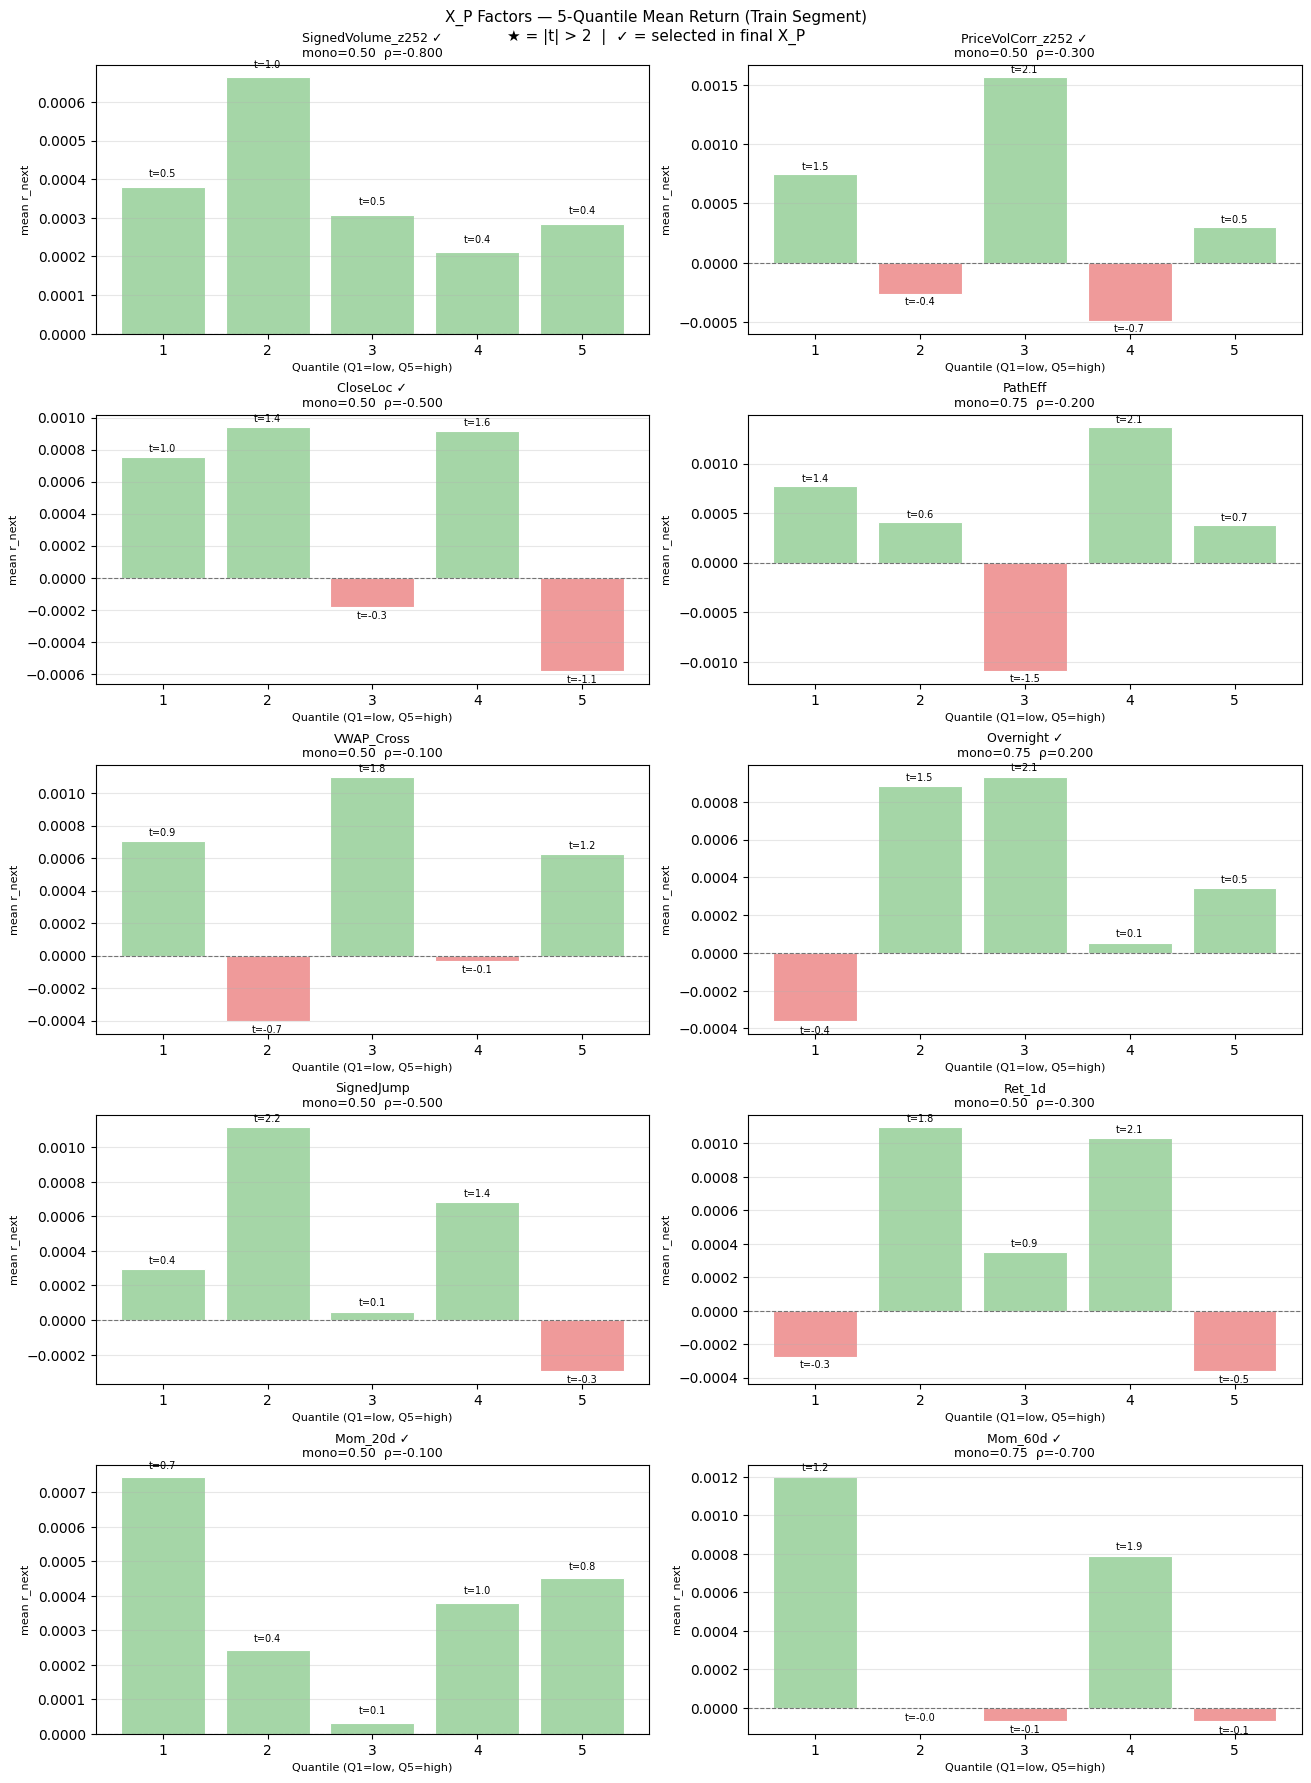


Plot saved to: data\xp_monotonicity.png


In [90]:
# ══════════════════════════════════════════════════════════════
# X_P 因子 5-Quantile Monotonicity Table
# 粘贴位置：Cell 30（selected_p 定义后）之后，Cell 32 之前
# 依赖变量：P_train_tfm, r_next_train, X_P_CANDIDATES, selected_p
# ══════════════════════════════════════════════════════════════

N_QUANTILES = 5

def quantile_monotonicity(factor_series, target_series, n_q=N_QUANTILES):
    """
    将因子按 n_q 等分位数切分，计算每个分位数桶内的：
      - 样本数 n
      - 平均下期收益 mean_ret
      - t 统计量（单样本 t-test，H0: mean=0）
    并计算单调性指标：
      - monotone_ratio: 相邻桶间方向一致的比例（越接近1越好）
      - rank_corr: 桶均值与桶编号的 Spearman 相关（完美单调=1或-1）
    """
    df = pd.DataFrame({'x': factor_series, 'y': target_series}).dropna()
    df['q_bin'] = pd.qcut(df['x'], q=n_q, labels=False, duplicates='drop')

    rows = []
    for q in sorted(df['q_bin'].unique()):
        sub = df.loc[df['q_bin'] == q, 'y'].values
        n   = len(sub)
        mu  = sub.mean()
        se  = sub.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
        t   = mu / se if se and se > 0 else np.nan
        rows.append({'Q': int(q) + 1, 'n': n, 'mean_ret': mu, 't_stat': t})

    tbl = pd.DataFrame(rows)

    # 单调性指标
    means = tbl['mean_ret'].values
    n_pairs      = len(means) - 1
    mono_steps   = np.sign(np.diff(means))      # +1 递增 / -1 递减
    dominant_dir = np.sign(means[-1] - means[0])  # 整体方向
    mono_ratio   = (mono_steps == dominant_dir).sum() / n_pairs if n_pairs > 0 else np.nan
    rank_corr    = spearmanr(tbl['Q'].values, means).correlation

    return tbl, mono_ratio, rank_corr, dominant_dir


# ── 1. 对所有 X_P 候选因子跑 monotonicity test ───────────────
mono_summary_rows = []

print("=" * 70)
print("X_P Factors — 5-Quantile Monotonicity Test (Train Segment)")
print("=" * 70)

for f in X_P_CANDIDATES:
    tbl, mono_ratio, rank_corr, direction = quantile_monotonicity(
        P_train_tfm[f], r_next_train, n_q=N_QUANTILES
    )

    # 每个因子打印详细分桶表
    print(f"\n{'─'*50}")
    print(f"Factor: {f}  |  direction={'↑' if direction > 0 else '↓'}  "
          f"|  mono_ratio={mono_ratio:.2f}  |  rank_corr={rank_corr:.3f}")
    print(f"{'─'*50}")
    header = f"  {'Q':>3}  {'n':>6}  {'mean_ret':>10}  {'t_stat':>8}"
    print(header)
    for _, row in tbl.iterrows():
        flag = " ★" if abs(row['t_stat']) > 2.0 else ""   # 标注显著桶
        print(f"  {int(row['Q']):>3}  {int(row['n']):>6}  "
              f"{row['mean_ret']:>10.5f}  {row['t_stat']:>8.2f}{flag}")

    mono_summary_rows.append({
        'factor':       f,
        'in_selected':  f in selected_p,
        'direction':    '+' if direction > 0 else '-',
        'mono_ratio':   round(mono_ratio, 3),
        'rank_corr':    round(rank_corr, 3),
        'Q1_mean':      tbl.loc[tbl['Q'] == 1, 'mean_ret'].values[0],
        'Q3_mean':      tbl.loc[tbl['Q'] == 3, 'mean_ret'].values[0],
        'Q5_mean':      tbl.loc[tbl['Q'] == 5, 'mean_ret'].values[0],
        'Q5_minus_Q1':  (tbl.loc[tbl['Q'] == 5, 'mean_ret'].values[0]
                         - tbl.loc[tbl['Q'] == 1, 'mean_ret'].values[0]),
    })

# ── 2. 汇总表：所有因子的单调性对比 ─────────────────────────
mono_summary = (pd.DataFrame(mono_summary_rows)
                .sort_values('rank_corr', key=abs, ascending=False))

print("\n\n" + "=" * 70)
print("Summary: Monotonicity across all X_P Candidates")
print("=" * 70)
print(mono_summary.to_string(index=False))

# ── 3. 可视化：每个因子的 5-quantile bar chart ───────────────
n_factors  = len(X_P_CANDIDATES)
n_cols     = 2
n_rows_fig = (n_factors + 1) // n_cols

fig, axes = plt.subplots(n_rows_fig, n_cols,
                          figsize=(13, 3.5 * n_rows_fig),
                          constrained_layout=True)
axes = axes.flatten()

for ax_i, f in enumerate(X_P_CANDIDATES):
    tbl, mono_ratio, rank_corr, direction = quantile_monotonicity(
        P_train_tfm[f], r_next_train, n_q=N_QUANTILES
    )
    ax = axes[ax_i]
    colors = ['#EF9A9A' if v < 0 else '#A5D6A7' for v in tbl['mean_ret']]
    ax.bar(tbl['Q'], tbl['mean_ret'], color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)

    # 在每根 bar 上标注 t-stat
    for _, row in tbl.iterrows():
        va  = 'bottom' if row['mean_ret'] >= 0 else 'top'
        off = 0.00002 if row['mean_ret'] >= 0 else -0.00002
        ax.text(row['Q'], row['mean_ret'] + off,
                f"t={row['t_stat']:.1f}", ha='center', va=va, fontsize=7)

    sel_marker = ' ✓' if f in selected_p else ''
    ax.set_title(f"{f}{sel_marker}\nmono={mono_ratio:.2f}  ρ={rank_corr:.3f}",
                 fontsize=9)
    ax.set_xlabel('Quantile (Q1=low, Q5=high)', fontsize=8)
    ax.set_ylabel('mean r_next', fontsize=8)
    ax.set_xticks(tbl['Q'])
    ax.grid(True, axis='y', alpha=0.3)

# 隐藏多余的子图
for ax_j in range(len(X_P_CANDIDATES), len(axes)):
    axes[ax_j].set_visible(False)

fig.suptitle('X_P Factors — 5-Quantile Mean Return (Train Segment)\n'
             '★ = |t| > 2  |  ✓ = selected in final X_P',
             fontsize=11, y=1.01)
plt.savefig(OUT_DIR / 'xp_monotonicity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {OUT_DIR / 'xp_monotonicity.png'}")

---
## 22.Save Outputs

In [89]:
factor_validation_full = {
    'X_HMM_correlation_matrix': hmm_corr.to_dict(),
    'X_P_correlation_matrix': p_corr.to_dict(),

}


selection = {
    'X_HMM': {
        'factors': selected_hmm,
        'transforms': {f: HMM_TRANSFORMS[f][0] for f in selected_hmm},
    },
    'X_P': {
        'factors': selected_p,
        'transforms': {f: P_TRANSFORMS[f][0] for f in selected_p},
    },
    'train_period': {
        'start': str(train_start.date()),
        'end':   str(train_end.date()),
        'n_obs': len(F_train),
    },
}

with open(OUT_DIR / 'factor_selection.json', 'w') as f:
    json.dump(selection, f, indent=2)


print(f"Saved: {OUT_DIR}/factor_selection.json")
print(f"\n=== Final Selection ===")
print(f"X_HMM ({len(selected_hmm)}): {selected_hmm}")
print(f"X_P   ({len(selected_p)}): {selected_p}")

Saved: data/factor_selection.json

=== Final Selection ===
X_HMM (7): ['RV_open30', 'RV_close30', 'Jump', 'VR_5_1', 'Ret_1d', 'Mom_20d', 'Mom_60d']
X_P   (6): ['CloseLoc', 'SignedVolume_z252', 'PriceVolCorr_z252', 'Overnight', 'Mom_20d', 'Mom_60d']
